# Analysis Online Inference Rate

In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path(os.getcwd())
PATH_DATA = HERE.parent / '01_aggregated_datasets' / 'inference_online_rate_llama3_70b'

In [3]:
from utilities import plot_setup, plot_options_default, save_figure, set_min_ticks

In [4]:
# plotting options
_ = plot_setup(plot_options_default)

## Read Data

In [5]:
# path for data
path_results = PATH_DATA / 'metadata.csv'

# save path
output_directory = HERE / "plots" 
save_flag = 1

In [6]:
df_results = pd.read_csv(path_results)
df_results.head()

,burstiness,dataset-name,dataset-path,end_time_exc,id,num-prompts,request_rate,start_time_exc,start_time,end_time,run_completed,execution_time_seconds,path_run,peak_power[W],mean_power[W]
0,100000,hf,likaixin/InstructCoder,2026-01-05 05:34:32.714319,1,300,1,2026-01-05 05:31:32.714319,2026-01-05 05:31:32.714319,2026-01-05 05:34:32.714319,True,179.954,/projects/aiuserapps/genai_power_dataset/01_ag...,2097.831345,2069.548985
1,100000,hf,likaixin/InstructCoder,2026-01-05 05:39:52.753836,2,600,2,2026-01-05 05:36:52.753836,2026-01-05 05:36:52.753836,2026-01-05 05:39:52.753836,True,179.846,/projects/aiuserapps/genai_power_dataset/01_ag...,2118.523541,2085.325478
2,100000,hf,likaixin/InstructCoder,2026-01-05 05:45:12.801867,3,900,3,2026-01-05 05:42:12.801867,2026-01-05 05:42:12.801867,2026-01-05 05:45:12.801867,True,179.943,/projects/aiuserapps/genai_power_dataset/01_ag...,2140.690436,2088.905829
3,100000,hf,likaixin/InstructCoder,2026-01-05 05:50:32.851132,4,1200,4,2026-01-05 05:47:32.851132,2026-01-05 05:47:32.851132,2026-01-05 05:50:32.851132,True,179.858,/projects/aiuserapps/genai_power_dataset/01_ag...,2163.157688,2090.571124
4,100000,hf,likaixin/InstructCoder,2026-01-05 05:55:52.901622,5,1500,5,2026-01-05 05:52:52.901622,2026-01-05 05:52:52.901622,2026-01-05 05:55:52.901622,True,179.988,/projects/aiuserapps/genai_power_dataset/01_ag...,2133.023660,2091.841939


# Power Profiles Plots

In [7]:
map_dataset = {
    'likaixin/InstructCoder':"Coding Dataset",
    'mgoin/mlperf-inference-llama2-data':"Conversation Dataset"
}

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/02_analysis_scripts/plots/2026-03-20_online_inference_finite_power.png


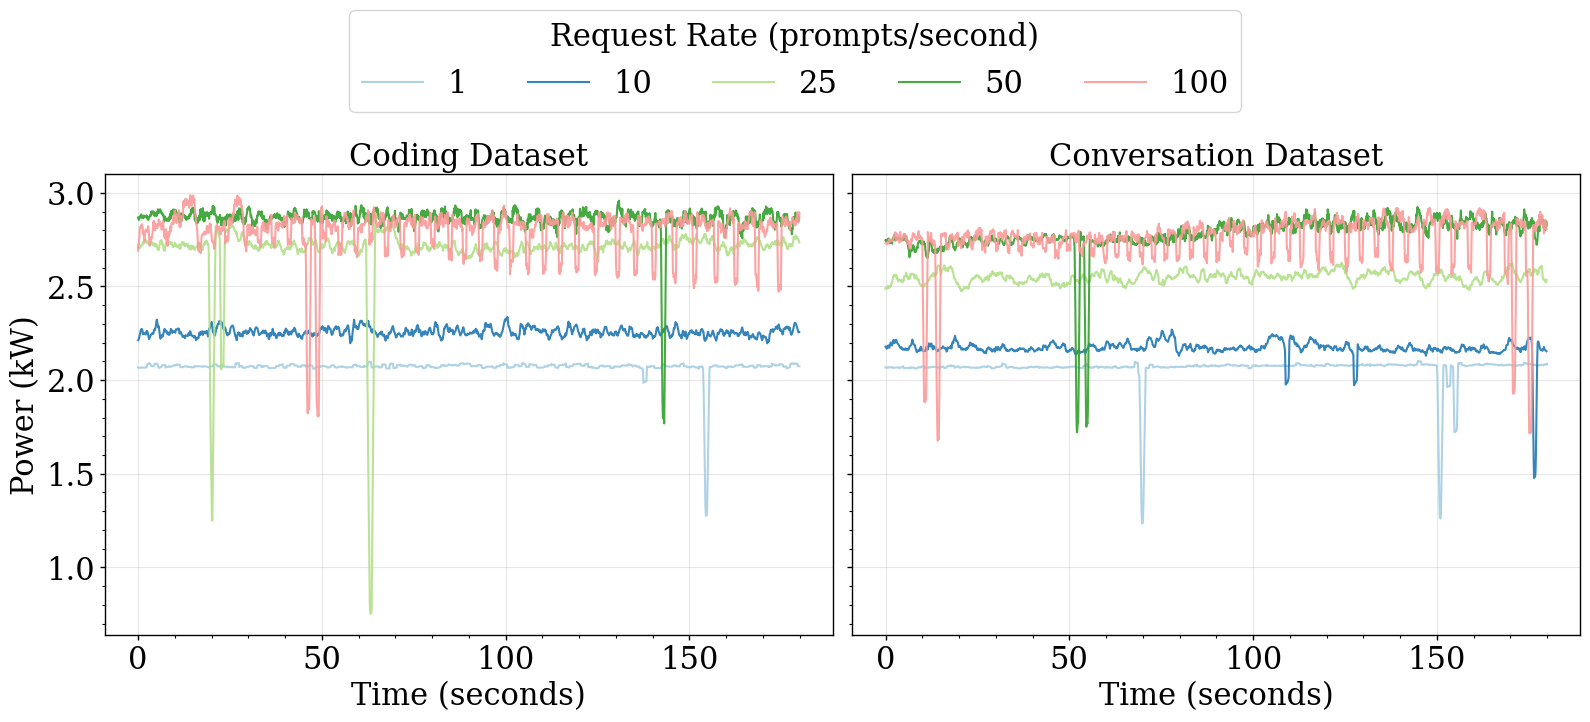

In [8]:
def plot_group_timeseries(df_results, groupby_cols, subplot_col):
    """
    Load timeseries for each group and create subplots by subplot_col.
    Plots only the median series for each request rate.
    
    Parameters:
    -----------
    df_results : DataFrame
        Results dataframe with 'path_run' column
    groupby_cols : list
        Columns to group by (will determine colors)
    subplot_col : str
        Column to create separate subplot columns for (e.g., 'dataset-path')
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    
    # Get unique values for subplot columns
    subplot_values = sorted(df_results[subplot_col].unique())
    n_subplots = len(subplot_values)
    
    # Group by all columns except subplot_col
    other_cols = [col for col in groupby_cols if col != subplot_col]
    
    # Get unique request rates and assign colors
    if 'request_rate' in other_cols:
        unique_rates = sorted(df_results['request_rate'].unique())
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        rate_color_map = {rate: colors[i % len(colors)] for i, rate in enumerate(unique_rates)}
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, n_subplots, figsize=(8*n_subplots, 6), sharey=True)
    if n_subplots == 1:
        axes = [axes]
    
    # Store handles and labels for legend
    handles_dict = {}
    labels_dict = {}
    
    for ax, subplot_val in zip(axes, subplot_values):
        # Filter data for this specific subplot
        df_filtered = df_results[df_results[subplot_col] == subplot_val]
        
        if len(df_filtered) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{subplot_col}={subplot_val}")
            continue
        
        # Load timeseries grouped by groupby_cols (excluding subplot_col)
        for group_name, group_df in df_filtered.groupby(other_cols):
            # Get color based on request rate
            if isinstance(group_name, tuple):
                rate_idx = [i for i, col in enumerate(other_cols) if col == 'request_rate'][0]
                request_rate = group_name[rate_idx]
                label = f"{request_rate}"
            else:
                request_rate = group_name
                label = f"{request_rate}"
            
            color = rate_color_map[request_rate]
            
            # Load all timeseries for this group
            all_timeseries = []
            for idx, row in group_df.iterrows():
                paths = row["path_run"] if isinstance(row["path_run"], list) else [row["path_run"]]
                for run_path in paths:
                    ts = pd.read_parquet(run_path)["power[W]"] * 1e-3  # Convert to kW
                    ts.index = ts.index.round(4)
                    all_timeseries.append(ts)
            
            # Combine all timeseries and compute median
            if len(all_timeseries) > 0:
                # Concatenate all series into a DataFrame
                df_combined = pd.concat(all_timeseries, axis=1)
                # Compute median across columns
                median_series = df_combined.median(axis=1)
                
                # Plot median series
                line, = ax.plot(median_series.index, median_series.values, 
                               color=color, linewidth=1.5, alpha=0.9)
                
                # Store handle and label for legend (one per request rate)
                if request_rate not in handles_dict:
                    handles_dict[request_rate] = line
                    labels_dict[request_rate] = label
        
        ax.set_title(map_dataset[subplot_val])
        ax.set_xlabel("Time (seconds)")
        ax.grid(alpha=0.3)
    
    # Set y-label only on leftmost subplot
    axes[0].set_ylabel("Power (kW)")
    
    # Add a single legend below the figure, sorted by request rate
    sorted_rates = sorted(handles_dict.keys())
    handles = [handles_dict[rate] for rate in sorted_rates]
    labels = [labels_dict[rate] for rate in sorted_rates]
    
    fig.legend(
        handles, 
        labels, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 1), 
        ncol=min(len(labels), 5),
        frameon=True,
        title="Request Rate (prompts/second)"
    )
    
    plt.tight_layout()
    
    return fig, axes


# Example usage with filtered request rates:
# Each request rate will get a different color in the same subplot
request_rates_to_plot = [1, 10, 25, 50, 100]
df_filtered = df_results[df_results['request_rate'].isin(request_rates_to_plot)]

fig, axes = plot_group_timeseries(
    df_filtered, 
    groupby_cols=['request_rate'], 
    subplot_col='dataset-path'
)

for ax in axes.flatten():
    ax = set_min_ticks(ax, "y", "major", 5)
    ax = set_min_ticks(ax, "y", "minor", 5)
    ax = set_min_ticks(ax, "x", "minor", 5)

save_figure(
    fig, 
    "online_inference_finite_power", 
    file_format=["png"],  # ["svg", "png", "pdf"]
    full_path=output_directory,
    save_flag=save_flag
)